<a href="https://colab.research.google.com/github/zerobraincells17/24CD3043_SonuKumarSingh_CNN_Lab/blob/main/24CD3043_SonuKumarSingh_CNN_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


### Task 1: Environment Setup & Data Pipeline

### Problem 1: Environment Verification

In [ ]:
# import libraries
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# version check
print("tf version:", tf.__version__)
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("matplotlib:", plt.matplotlib.__version__)

# gpu check
gpu = tf.config.list_physical_devices('GPU')

if len(gpu) > 0:
    print("GPU available")
else:
    print("GPU not available, using CPU")

# CPU is slower becoz of sequentially computation
# GPU is faster due to parallel processing...which is often used in DL

tf version: 2.19.0
numpy: 2.0.2
pandas: 2.2.2
matplotlib: 3.10.0
GPU available


### Problem 2: Dataset Exploration

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
MNIST train shape: (60000, 28, 28)
MNIST test shape: (10000, 28, 28)
CIFAR train shape: (50000, 32, 32, 3)
CIFAR test shape: (10000, 32, 32, 3)

MNIST dtype: uint8
MNIST range: 0 to 255

CIFAR dtype: uint8
CIFAR range: 0 to 255

MNIST class distribution:
Digit 0 : 5923
Digit 1 : 6742
Digit 2 : 5958
Digit 3 : 6131
Digit 4 : 5842
Digit 5 : 5421
Digit 6 : 5918
Digit 7 : 6265
Digit 8 : 5851
Digit 9 : 5949


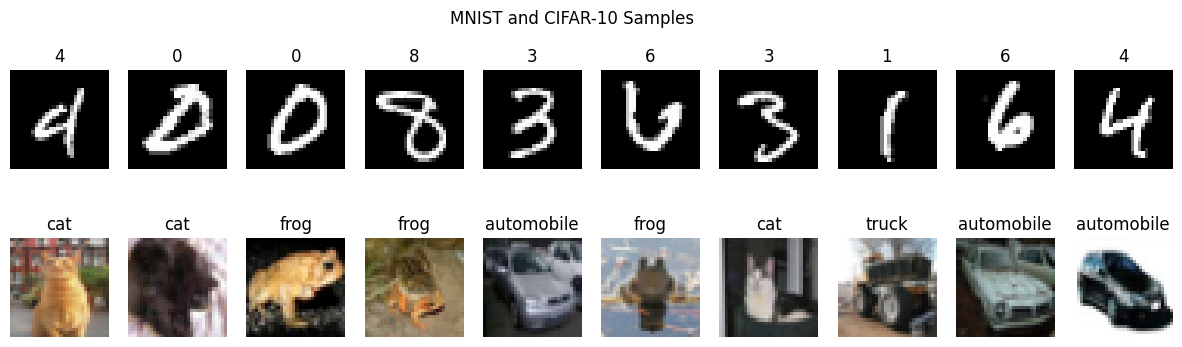

In [ ]:
# loading datasets
from tensorflow.keras.datasets import mnist, cifar10

(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = mnist.load_data()
(x_train_cifar, y_train_cifar), (x_test_cifar, y_test_cifar) = cifar10.load_data()


# checking shapes
print("MNIST train shape:", x_train_mnist.shape)
print("MNIST test shape:", x_test_mnist.shape)

print("CIFAR train shape:", x_train_cifar.shape)
print("CIFAR test shape:", x_test_cifar.shape)


# dtype and value range
print("\nMNIST dtype:", x_train_mnist.dtype)
print("MNIST range:", x_train_mnist.min(), "to", x_train_mnist.max())

print("\nCIFAR dtype:", x_train_cifar.dtype)
print("CIFAR range:", x_train_cifar.min(), "to", x_train_cifar.max())


# class distribution (MNIST)
values, counts = np.unique(y_train_mnist, return_counts=True)

print("\nMNIST class distribution:")
for i in range(len(values)):
    print("Digit", values[i], ":", counts[i])


# plotting samples
import matplotlib.pyplot as plt

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

plt.figure(figsize=(15,4))

# MNIST (top row)
for i in range(10):
    idx = np.random.randint(0, len(x_train_mnist))
    plt.subplot(2,10,i+1)
    plt.imshow(x_train_mnist[idx], cmap='gray')
    plt.title(str(y_train_mnist[idx]))
    plt.axis('off')

# CIFAR (bottom row)
for i in range(10):
    idx = np.random.randint(0, len(x_train_cifar))
    plt.subplot(2,10,i+11)
    plt.imshow(x_train_cifar[idx])
    plt.title(class_names[y_train_cifar[idx][0]])
    plt.axis('off')

plt.suptitle("MNIST and CIFAR-10 Samples")
plt.savefig("dataset_samples.png")
plt.show()

### Problem 3: Preprocessing Pipeline

In [ ]:
# preprocessing function

def preprocess_data(x, y, is_mnist=False):

    print("Before preprocessing:")
    print("shape:", x.shape)
    print("dtype:", x.dtype)
    print("sample values:", x[0][0][:5])


    # normalize
    x = x.astype('float32') / 255.0


    # reshape for MNIST
    if is_mnist:
        x = x.reshape(x.shape[0], 28, 28, 1)


    # one-hot encoding
    y_onehot = np.zeros((len(y), 10))

    for i in range(len(y)):
        y_onehot[i][y[i]] = 1


    print("\nAfter preprocessing:")
    print("shape:", x.shape)
    print("dtype:", x.dtype)
    print("sample values:", x[0][0][:5])

    print("label example:", y[0], "->", y_onehot[0])

    return x, y_onehot

In [ ]:
# MNIST
x_train_mnist_p, y_train_mnist_p = preprocess_data(x_train_mnist, y_train_mnist, True)

# CIFAR
x_train_cifar_p, y_train_cifar_p = preprocess_data(x_train_cifar, y_train_cifar, False)

Before preprocessing:
shape: (60000, 28, 28)
dtype: uint8
sample values: [0 0 0 0 0]

After preprocessing:
shape: (60000, 28, 28, 1)
dtype: float32
sample values: [[0.]
 [0.]
 [0.]
 [0.]
 [0.]]
label example: 5 -> [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
Before preprocessing:
shape: (50000, 32, 32, 3)
dtype: uint8
sample values: [[59 62 63]
 [43 46 45]
 [50 48 43]
 [68 54 42]
 [98 73 52]]

After preprocessing:
shape: (50000, 32, 32, 3)
dtype: float32
sample values: [[0.23137255 0.24313726 0.24705882]
 [0.16862746 0.18039216 0.1764706 ]
 [0.19607843 0.1882353  0.16862746]
 [0.26666668 0.21176471 0.16470589]
 [0.38431373 0.28627452 0.20392157]]
label example: [6] -> [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


### Problem 4: Data Augmentation Pipeline

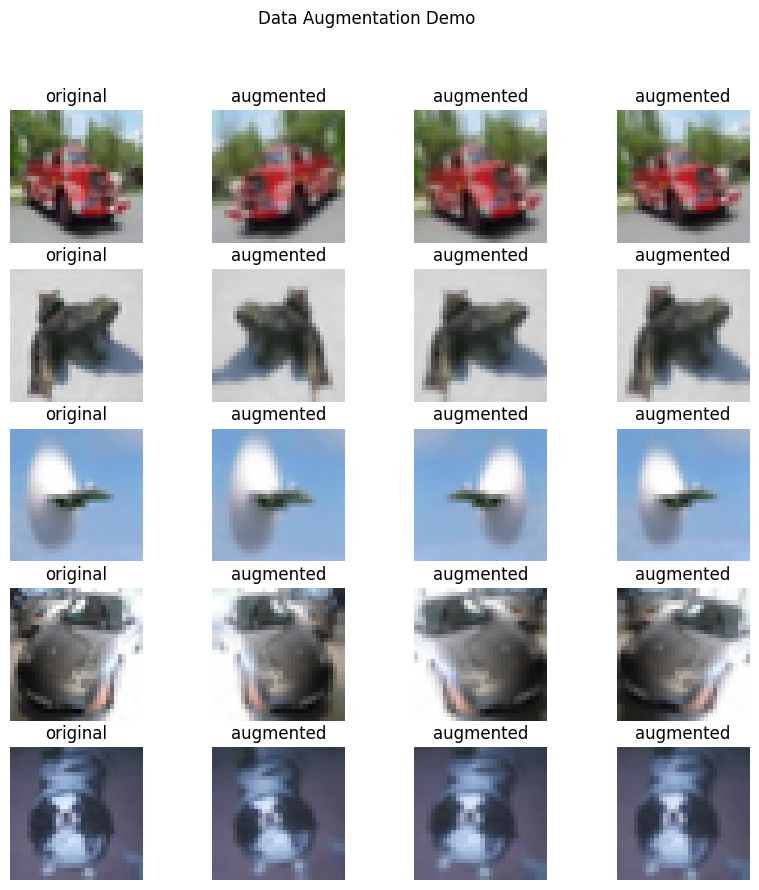

In [ ]:
# data augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.1
)

# pick 5 random images
indices = np.random.choice(len(x_train_cifar), 5)

plt.figure(figsize=(10,10))

for i, idx in enumerate(indices):

    img = x_train_cifar[idx]

    # original image
    plt.subplot(5,4,i*4 + 1)
    plt.imshow(img)
    plt.title("original")
    plt.axis('off')

    # generate 3 augmented versions
    img = img.reshape((1,) + img.shape)   # reshape needed

    aug_iter = datagen.flow(img, batch_size=1)

    for j in range(3):
        aug_img = next(aug_iter)[0].astype('uint8')

        plt.subplot(5,4,i*4 + j + 2)
        plt.imshow(aug_img)
        plt.title("augmented")
        plt.axis('off')

plt.suptitle("Data Augmentation Demo")
plt.savefig("augmentation_demo.png")
plt.show()

Q1. What does the channel dimension represent in a tensor of shape (N, H, W, C)? Explain with reference to
both a greyscale image and an RGB image.

Answer Q1:
The channel dimension (C) represents the no. of color channels in an image...
in a grayscale there is only one channel becoz each pixel has a single intensity value, so the shape becomes (N, H, W, 1).in an RGB image, there are three channels RGB, so the shape becomes (N, H, W, 3).
Each channel stores different info about the image, and together they form the complete picture.

Q2. CIFAR-10 images are 32×32 pixels. If you were training a CNN on 1024×1024 satellite images, what
data loading strategies would you use to avoid running out of memory? Name at least two techniques and
explain how each one helps.

Answer Q2:
For very large images like 1024×1024, loading all data at once can cause memory issues. we can use batch loading, where only a small no.of images are loaded and processed at a time instead of the entire dataset(which ofcourse reduced the memory consumption).
Another technique is image downsampling(max pooling,avy pooling), where images are reduced to a smaller size before training, which decreases memory usage.These methods help reduce memory consumption and make training feasible on limited hardware.


Q3. Suppose a student applies normalisation to the test set using the mean and standard deviation
computed from the test set itself. What is wrong with this approach?

Answer Q3:
This is wrong becoz the test set should be completely unseen like if we use its mean and standard deviation, we are indirectly using information from the test data, which leads to data leakage. This makes the model evaluation unfair. instead, normalization should be based only on training data ...not test data.

### Task 2: Building a CNN from Scratch

### Problem 1: Manual 2D Convolution (NumPy only)

In [ ]:
def conv2d(image, kernel, stride=1, padding=0):

    # apply padding
    if padding > 0:
        image = np.pad(image, ((padding, padding), (padding, padding)), mode='constant')

    img_h, img_w = image.shape
    k_h, k_w = kernel.shape

    # output size
    out_h = (img_h - k_h)//stride + 1
    out_w = (img_w - k_w)//stride + 1

    output = np.zeros((out_h, out_w))

    # convolution (actually cross-correlation as used in CNNs)
    for i in range(out_h):
        for j in range(out_w):

            patch = image[i:i+k_h, j:j+k_w]
            output[i, j] = np.sum(patch * kernel)

    return output

In [ ]:
image = np.array([
    [3,1,0,2,4],
    [1,5,3,2,1],
    [0,2,6,4,3],
    [2,3,1,5,2],
    [1,0,2,3,4]
])

kernel = np.array([
    [-1,0,1],
    [-2,0,2],
    [-1,0,1]
])

out = conv2d(image, kernel)

print("Output:\n", out)
print("Shape:", out.shape)

Output:
 [[ 7. -3. -3.]
 [13.  3. -7.]
 [ 5.  9.  1.]]
Shape: (3, 3)


### Problem 2: Output Size Derivation

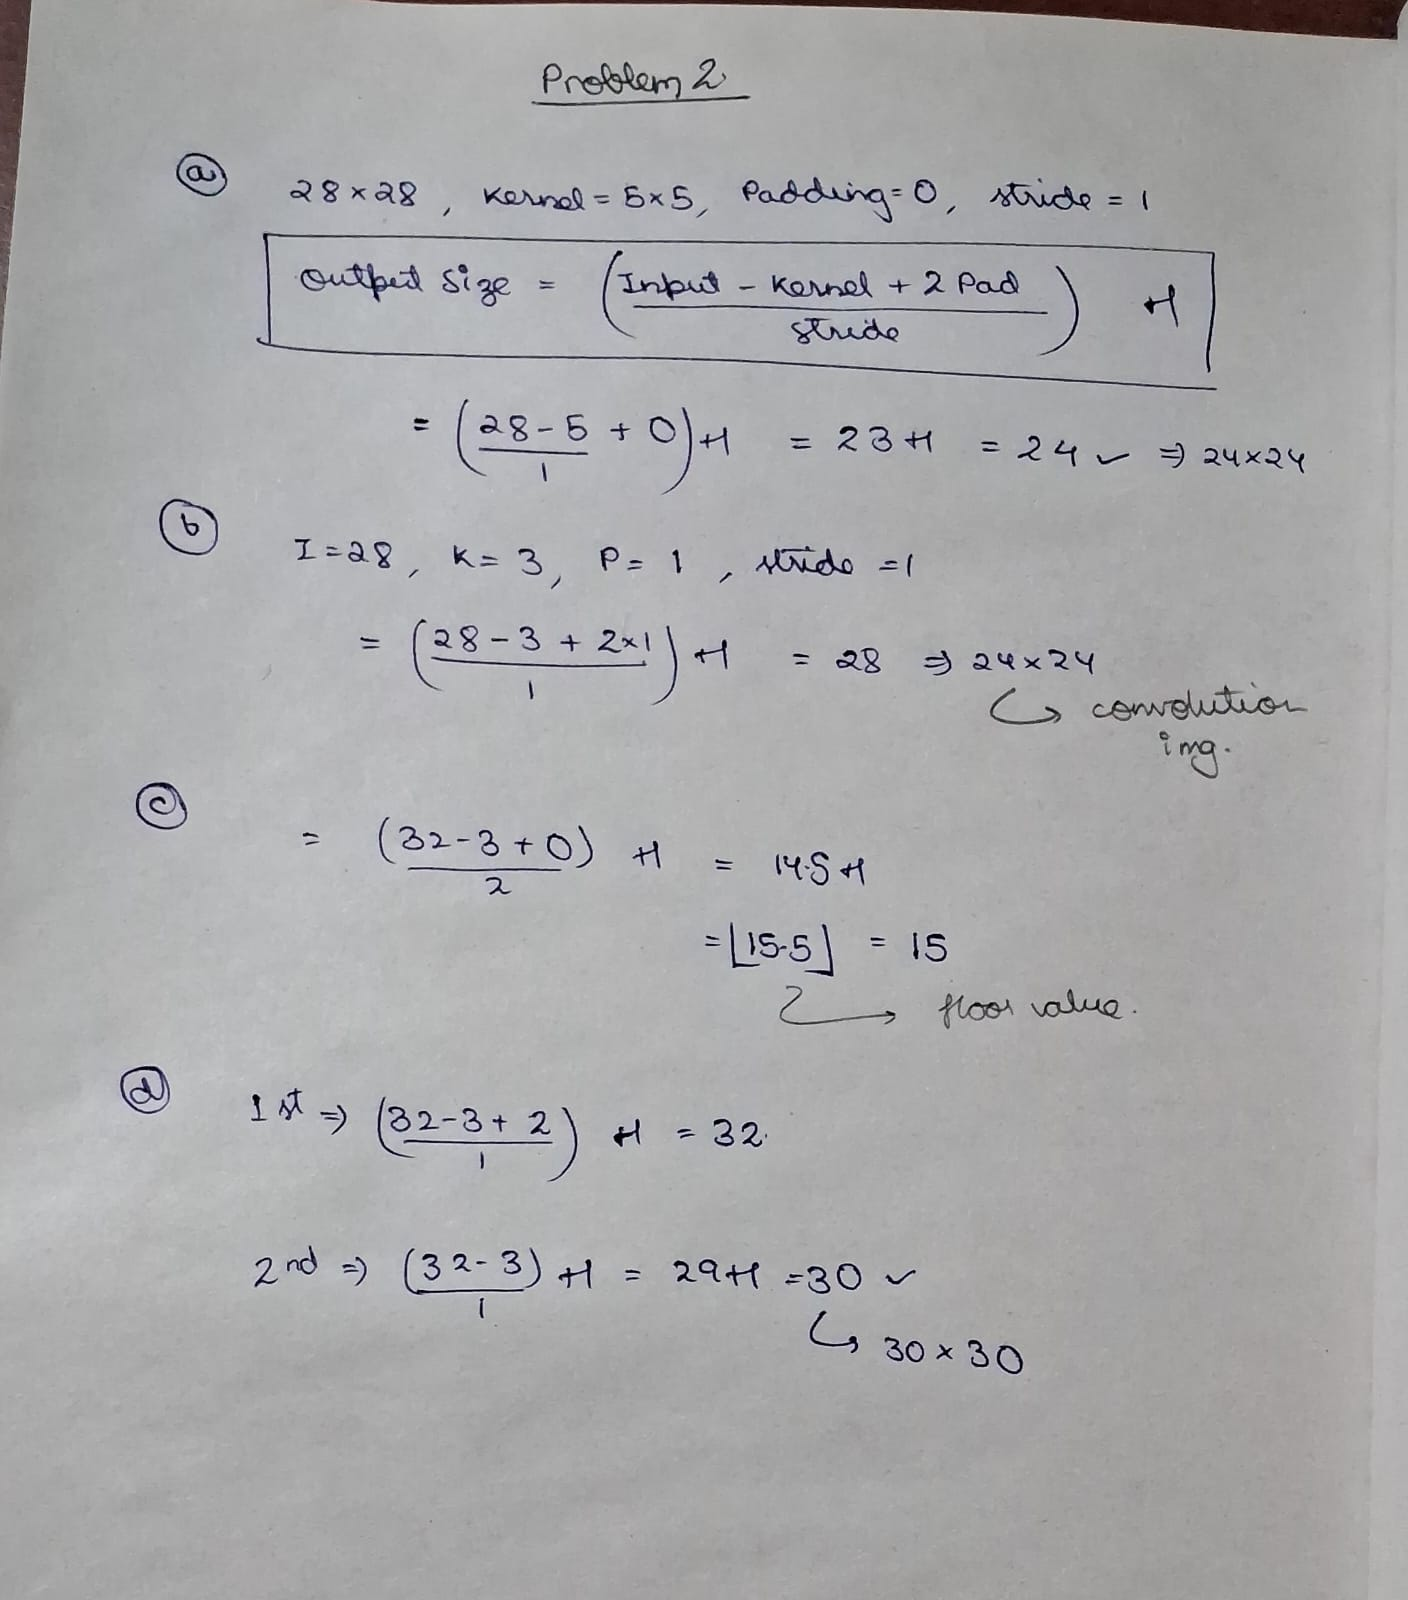

### Problem 3: Implement LeNet-5

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense, Activation

model = Sequential()

# Conv Layer 1
model.add(Conv2D(6, (5,5), padding='valid', input_shape=(28,28,1)))
model.add(Activation('tanh'))
model.add(AveragePooling2D(pool_size=(2,2), strides=2))

# Conv Layer 2
model.add(Conv2D(16, (5,5), padding='valid'))
model.add(Activation('tanh'))
model.add(AveragePooling2D(pool_size=(2,2), strides=2))

# Flatten
model.add(Flatten())

# Dense layers
model.add(Dense(120))
model.add(Activation('tanh'))

model.add(Dense(84))
model.add(Activation('tanh'))

model.add(Dense(10, activation='softmax'))

# summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 24, 24, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 84)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

### Problem 4: Design a Custom CNN for CIFAR-10

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation
from tensorflow.keras.layers import MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.layers import Dense, Dropout

model = Sequential()

# block 1
model.add(Conv2D(64, (3,3), padding='same', input_shape=(32,32,3)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# block 2
model.add(Conv2D(128, (3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# block 3
model.add(Conv2D(256, (3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# classification head
model.add(GlobalAveragePooling2D())

model.add(Dense(128))
model.add(Activation('relu'))
model.add(Dropout(0.5))

model.add(Dense(10, activation='softmax'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 406,794 (1.55 MB)

 Trainable params: 405,898 (1.55 MB)

 Non-trainable params: 896 (3.50 KB)

Q1. Compare the parameter efficiency of two stacked 3×3 Conv layers versus one 5×5 Conv layer on the
same input with the same number of filters. Which uses fewer parameters? Show numerical proof and
explain any other advantages of the smaller kernel approach.
answer:
Two 3×3 conv layers are actually more efficient than one 5×5 layer.Like forex, if we take 64 input and output channels the 5×5 conv has around 102k parameters while two 3×3 layers together have only about 73k. So basically, we get similar coverage with fewer parameters.
Also, stacking two layers adds extra activation functions, which makes the model learn more complex patterns(non linearity).

Q2. What is the role of Batch Normalisation in a CNN? Where in the layer stack should it be placed (before or
after activation), and why? Mention at least two empirical benefits it provides during training
answer:
Batch Normalisation is used to stabilise and speed up training in a CNN by normalising the activations of each layer. It helps keep the values in a consistent range, which makes learning more stable.
It is usually placed after the convolution layer and before the activation function, because it normalises the raw outputs before applying non-linearity.
Some benefits are that it allows faster convergence during training and also reduces overfitting to some extent. It also helps in using higher learning rates without making training unstable.

Q3. Your custom CNN has a GlobalAveragePooling layer before the Dense head. What does this layer do
geometrically? What would happen to the parameter count and spatial information if you replaced it with
Flatten?
answer:
Global Average Pooling takes each feature map and computes the average of all its values, so it converts a 2D feature map into a single value per channel. Geometrically, it reduces each spatial map into one number, so the output becomes a vector with length equal to the number of channels.
If we replace it with Flatten, then all spatial values are kept, which means the output vector becomes much larger. This will significantly increase the number of parameters in the Dense layer. However, Flatten preserves spatial information, while Global Average Pooling loses detailed spatial structure but helps reduce overfitting.


### Task 3: Training, Tuning & Regularisation

### Problem 1: First Training Run

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 24, 24, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 84)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7777 - loss: 0.8778 - val_accuracy: 0.9065 - val_loss: 0.3787
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8935 - loss: 0.3865 - val_accuracy: 0.9268 - val_loss: 0.2793
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9114 - loss: 0.3127 - val_accuracy: 0.9375 - val_loss: 0.2336
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9232 - loss: 0.2676 - val_accuracy: 0.9468 - val_loss: 0.2016
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9325 - loss: 0.2329 - val_accuracy: 0.9520 - val_loss: 0.1765
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9406 - loss: 0.2044 - val_accuracy: 0.9603 - val_loss: 0.1559
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9478 - loss: 0.1805 - val_accuracy: 0.9647 - val_loss: 0.1391
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9539 - loss: 0.1606 - val_accuracy: 0.

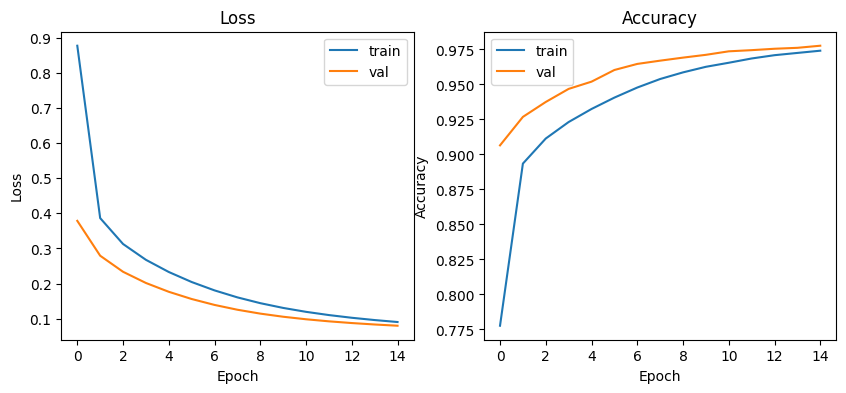

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9758 - loss: 0.0819
Final Test Accuracy: 0.9757999777793884


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# -------- load dataset --------
from tensorflow.keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# -------- preprocessing --------
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# reshape to (28,28,1)
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

# one-hot encoding
y_train_onehot = np.zeros((len(y_train),10))
for i in range(len(y_train)):
    y_train_onehot[i][y_train[i]] = 1

y_test_onehot = np.zeros((len(y_test),10))
for i in range(len(y_test)):
    y_test_onehot[i][y_test[i]] = 1


# -------- build LeNet --------
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense, Activation

lenet_model = Sequential()

lenet_model.add(Conv2D(6, (5,5), padding='valid', input_shape=(28,28,1)))
lenet_model.add(Activation('tanh'))
lenet_model.add(AveragePooling2D(pool_size=(2,2), strides=2))

lenet_model.add(Conv2D(16, (5,5), padding='valid'))
lenet_model.add(Activation('tanh'))
lenet_model.add(AveragePooling2D(pool_size=(2,2), strides=2))

lenet_model.add(Flatten())

lenet_model.add(Dense(120))
lenet_model.add(Activation('tanh'))

lenet_model.add(Dense(84))
lenet_model.add(Activation('tanh'))

lenet_model.add(Dense(10, activation='softmax'))

lenet_model.summary()


# -------- compile --------
lenet_model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


# -------- train --------
history = lenet_model.fit(
    x_train,
    y_train_onehot,
    epochs=15,
    batch_size=64,
    validation_split=0.1
)


# -------- plot --------
plt.figure(figsize=(10,4))

# loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.savefig("lenet_sgd_curves.png")
plt.show()


# -------- test accuracy --------
test_loss, test_acc = lenet_model.evaluate(x_test, y_test_onehot)

print("Final Test Accuracy:", test_acc)

### Problem 2: Optimiser Comparison

In [ ]:
def create_lenet():
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense, Activation

    model = Sequential()

    model.add(Conv2D(6, (5,5), padding='valid', input_shape=(28,28,1)))
    model.add(Activation('tanh'))
    model.add(AveragePooling2D(pool_size=(2,2), strides=2))

    model.add(Conv2D(16, (5,5), padding='valid'))
    model.add(Activation('tanh'))
    model.add(AveragePooling2D(pool_size=(2,2), strides=2))

    model.add(Flatten())

    model.add(Dense(120))
    model.add(Activation('tanh'))

    model.add(Dense(84))
    model.add(Activation('tanh'))

    model.add(Dense(10, activation='softmax'))

    return model

In [ ]:
# -------- SGD --------
model_sgd = create_lenet()
model_sgd.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

hist_sgd = model_sgd.fit(x_train, y_train_onehot,
                         epochs=15, batch_size=64, validation_split=0.1)


# -------- SGD + Momentum --------
model_mom = create_lenet()
model_mom.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

hist_mom = model_mom.fit(x_train, y_train_onehot,
                         epochs=15, batch_size=64, validation_split=0.1)


# -------- Adam --------
model_adam = create_lenet()
model_adam.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

hist_adam = model_adam.fit(x_train, y_train_onehot,
                           epochs=15, batch_size=64, validation_split=0.1)

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7346 - loss: 0.9769 - val_accuracy: 0.8998 - val_loss: 0.3970
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8862 - loss: 0.4040 - val_accuracy: 0.9223 - val_loss: 0.2855
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9067 - loss: 0.3241 - val_accuracy: 0.9363 - val_loss: 0.2376
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9193 - loss: 0.2787 - val_accuracy: 0.9455 - val_loss: 0.2056
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9283 - loss: 0.2452 - val_accuracy: 0.9507 - val_loss: 0.1811
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9358 - loss: 0.2181 - val_accuracy: 0.9567 - val_loss: 0.1613
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9424 - loss: 0.1954 - val_accuracy: 0.9617 - val_loss: 0.1448
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9480 - loss: 0.1761 - val_accuracy: 0.

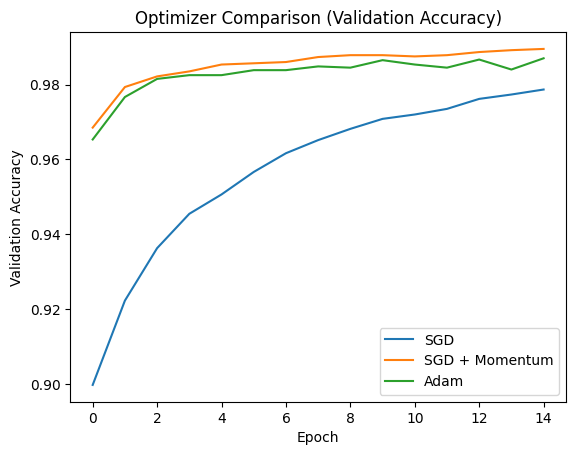

In [ ]:
import matplotlib.pyplot as plt

plt.plot(hist_sgd.history['val_accuracy'], label='SGD')
plt.plot(hist_mom.history['val_accuracy'], label='SGD + Momentum')
plt.plot(hist_adam.history['val_accuracy'], label='Adam')

plt.title("Optimizer Comparison (Validation Accuracy)")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()

plt.savefig("optimiser_comparison.png")
plt.show()

### Problem 3: Learning Rate & Batch Size Grid Search

In [ ]:
def create_model():
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation
    from tensorflow.keras.layers import MaxPooling2D, GlobalAveragePooling2D
    from tensorflow.keras.layers import Dense, Dropout

    model = Sequential()

    model.add(Conv2D(64, (3,3), padding='same', input_shape=(32,32,3)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2,2)))

    model.add(Conv2D(128, (3,3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2,2)))

    model.add(Conv2D(256, (3,3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2,2)))

    model.add(GlobalAveragePooling2D())

    model.add(Dense(128))
    model.add(Activation('relu'))
    model.add(Dropout(0.5))

    model.add(Dense(10, activation='softmax'))

    return model

In [ ]:
results = {}

learning_rates = [0.1, 0.01, 0.001]
batch_sizes = [32, 128]

for lr in learning_rates:
    for bs in batch_sizes:
        print("\nTraining with LR =", lr, "Batch Size =", bs)

        model = create_model()

        model.compile(
            optimizer=tf.keras.optimizers.SGD(learning_rate=lr),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        history = model.fit(
            x_train_cifar_p,
            y_train_cifar_p,
            epochs=10,
            batch_size=bs,
            validation_split=0.1,
            verbose=0
        )

        final_val_acc = history.history['val_accuracy'][-1]
        results[(lr, bs)] = final_val_acc

        print("Val Accuracy:", final_val_acc)


Training with LR = 0.1 Batch Size = 32
Val Accuracy: 0.656000018119812

Training with LR = 0.1 Batch Size = 128
Val Accuracy: 0.5644000172615051

Training with LR = 0.01 Batch Size = 32
Val Accuracy: 0.4848000109195709

Training with LR = 0.01 Batch Size = 128
Val Accuracy: 0.47699999809265137

Training with LR = 0.001 Batch Size = 32
Val Accuracy: 0.426800012588501

Training with LR = 0.001 Batch Size = 128
Val Accuracy: 0.4828000068664551


In [ ]:
print("\nFinal Results:")

for lr in learning_rates:
    row = []
    for bs in batch_sizes:
        row.append(round(results[(lr, bs)], 4))
    print("LR =", lr, ":", row)


Final Results:
LR = 0.1 : [0.656, 0.5644]
LR = 0.01 : [0.4848, 0.477]
LR = 0.001 : [0.4268, 0.4828]


### Problem 4: Regularisation Experiment

In [ ]:
def create_base_model():
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation

    model = Sequential()

    model.add(Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)))
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2,2)))

    model.add(Conv2D(64, (3,3), padding='same'))
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2,2)))

    model.add(Flatten())
    model.add(Dense(128))
    model.add(Activation('relu'))

    model.add(Dense(10, activation='softmax'))

    return model

In [ ]:
model_a = create_base_model()

In [ ]:
def create_dropout_model():
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout

    model = Sequential()

    model.add(Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)))
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2,2)))
    model.add(Dropout(0.3))

    model.add(Conv2D(64, (3,3), padding='same'))
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2,2)))
    model.add(Dropout(0.3))

    model.add(Flatten())
    model.add(Dense(128))
    model.add(Activation('relu'))
    model.add(Dropout(0.5))

    model.add(Dense(10, activation='softmax'))

    return model

In [ ]:
def create_bn_model():
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, BatchNormalization

    model = Sequential()

    model.add(Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2,2)))

    model.add(Conv2D(64, (3,3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2,2)))

    model.add(Flatten())
    model.add(Dense(128))
    model.add(Activation('relu'))

    model.add(Dense(10, activation='softmax'))

    return model

In [ ]:
def create_full_model():
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization

    model = Sequential()

    model.add(Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2,2)))
    model.add(Dropout(0.3))

    model.add(Conv2D(64, (3,3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2,2)))
    model.add(Dropout(0.3))

    model.add(Flatten())
    model.add(Dense(128))
    model.add(Activation('relu'))
    model.add(Dropout(0.5))

    model.add(Dense(10, activation='softmax'))

    return model

In [ ]:
def train_model(model):
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(
        x_train_cifar_p,
        y_train_cifar_p,
        epochs=20,
        batch_size=64,
        validation_split=0.1,
        verbose=0
    )

    return history

In [ ]:
hist_a = train_model(create_base_model())
hist_b = train_model(create_dropout_model())
hist_c = train_model(create_bn_model())
hist_d = train_model(create_full_model())

In [ ]:
def get_gap(history):
    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    return train_acc - val_acc

In [ ]:
gap_a = get_gap(hist_a)
gap_b = get_gap(hist_b)
gap_c = get_gap(hist_c)
gap_d = get_gap(hist_d)

In [ ]:
print("\nTrain-Validation Accuracy Gaps:")

print("No Regularisation:", round(gap_a, 4))
print("Dropout only:", round(gap_b, 4))
print("BatchNorm only:", round(gap_c, 4))
print("Dropout + BatchNorm:", round(gap_d, 4))


Train-Validation Accuracy Gaps:
No Regularisation: 0.2729
Dropout only: -0.0434
BatchNorm only: 0.25
Dropout + BatchNorm: -0.1201


In [ ]:
def plot_history(history, title):
    import matplotlib.pyplot as plt

    plt.plot(history.history['accuracy'], label='train')
    plt.plot(history.history['val_accuracy'], label='val')

    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.show()

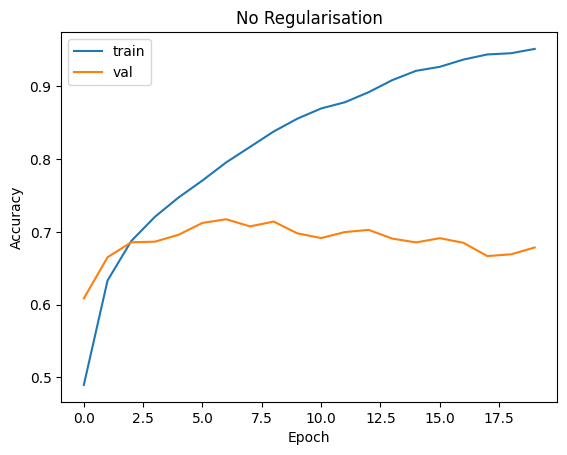

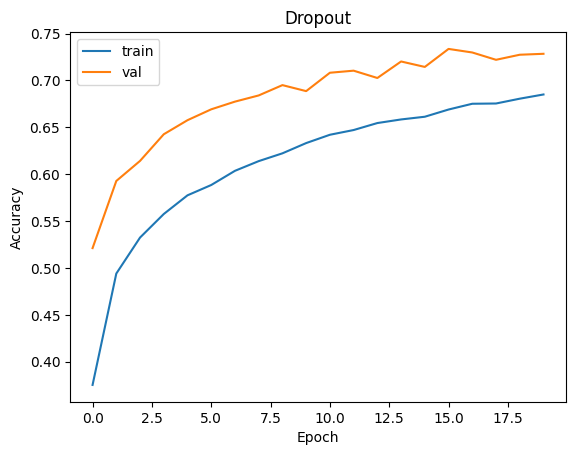

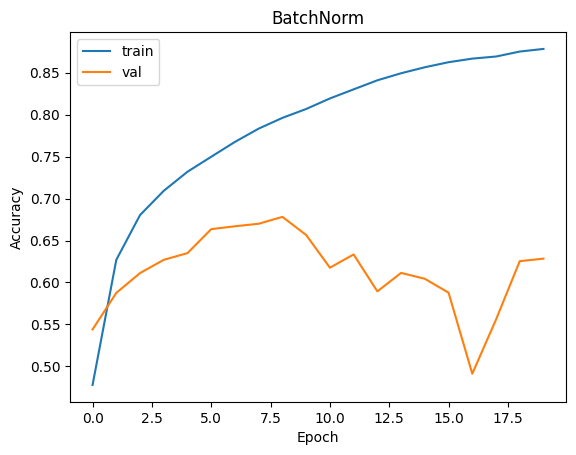

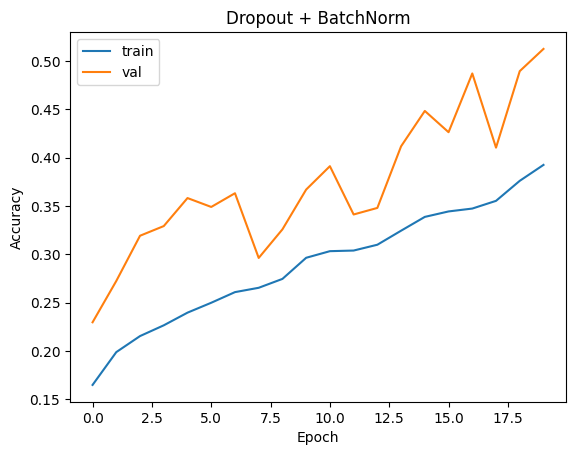

In [ ]:
plot_history(hist_a, "No Regularisation")
plot_history(hist_b, "Dropout")
plot_history(hist_c, "BatchNorm")
plot_history(hist_d, "Dropout + BatchNorm")

### Problem 5: Learning Rate Scheduling


Epoch 23: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


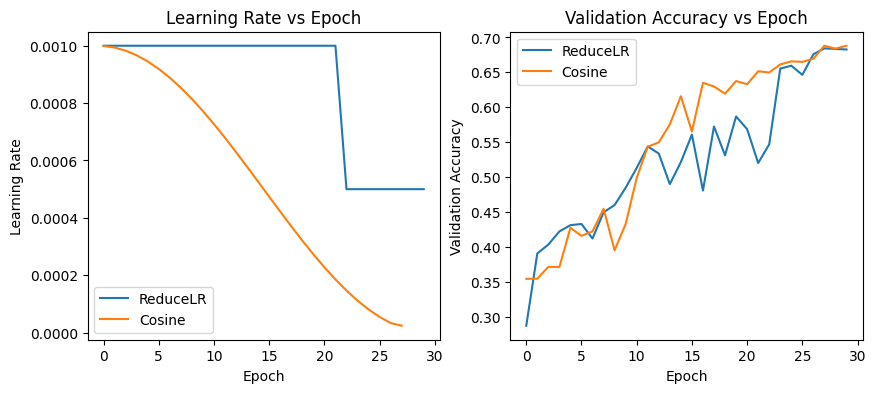

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

# -------- model (best one: dropout + batchnorm) --------
def create_full_model():
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
    from tensorflow.keras.layers import Activation, Dropout, BatchNormalization

    model = Sequential()

    model.add(Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2,2)))
    model.add(Dropout(0.3))

    model.add(Conv2D(64, (3,3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2,2)))
    model.add(Dropout(0.3))

    model.add(Flatten())
    model.add(Dense(128))
    model.add(Activation('relu'))
    model.add(Dropout(0.5))

    model.add(Dense(10, activation='softmax'))

    return model


# -------- ReduceLROnPlateau --------
from tensorflow.keras.callbacks import ReduceLROnPlateau

model_rlr = create_full_model()

model_rlr.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# callback
rlr_callback = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

# track LR manually
class LRTracker(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.lrs = []

    def on_epoch_end(self, epoch, logs=None):
        lr = self.model.optimizer.learning_rate
        self.lrs.append(float(tf.keras.backend.get_value(lr)))

lr_tracker_rlr = LRTracker()

history_rlr = model_rlr.fit(
    x_train_cifar_p,
    y_train_cifar_p,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=[rlr_callback, lr_tracker_rlr],
    verbose=0
)


# -------- Cosine Annealing --------
steps_per_epoch = len(x_train_cifar_p) // 64
total_steps = steps_per_epoch * 30

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=0.001,
    decay_steps=total_steps
)

model_cos = create_full_model()

model_cos.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# track LR
class CosineLRTracker(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.lrs = []

    def on_batch_end(self, batch, logs=None):
        lr = self.model.optimizer.learning_rate
        self.lrs.append(float(tf.keras.backend.get_value(lr)))

lr_tracker_cos = CosineLRTracker()

history_cos = model_cos.fit(
    x_train_cifar_p,
    y_train_cifar_p,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=[lr_tracker_cos],
    verbose=0
)

# average LR per epoch for cosine
import numpy as np
lr_cos_epoch = []
batches_per_epoch = steps_per_epoch

for i in range(30):
    start = i * batches_per_epoch
    end = (i+1) * batches_per_epoch
    lr_cos_epoch.append(np.mean(lr_tracker_cos.lrs[start:end]))


# -------- plotting --------
plt.figure(figsize=(10,4))

# LR plot
plt.subplot(1,2,1)
plt.plot(lr_tracker_rlr.lrs, label='ReduceLR')
plt.plot(lr_cos_epoch, label='Cosine')
plt.title("Learning Rate vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.legend()

# accuracy plot
plt.subplot(1,2,2)
plt.plot(history_rlr.history['val_accuracy'], label='ReduceLR')
plt.plot(history_cos.history['val_accuracy'], label='Cosine')
plt.title("Validation Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()

plt.savefig("lr_schedule_comparison.png")
plt.show()

### Task 4: Visualisation & Interpretability

### Problem 1: Visualise Learned Filters

Filter shape: (3, 3, 3, 32)


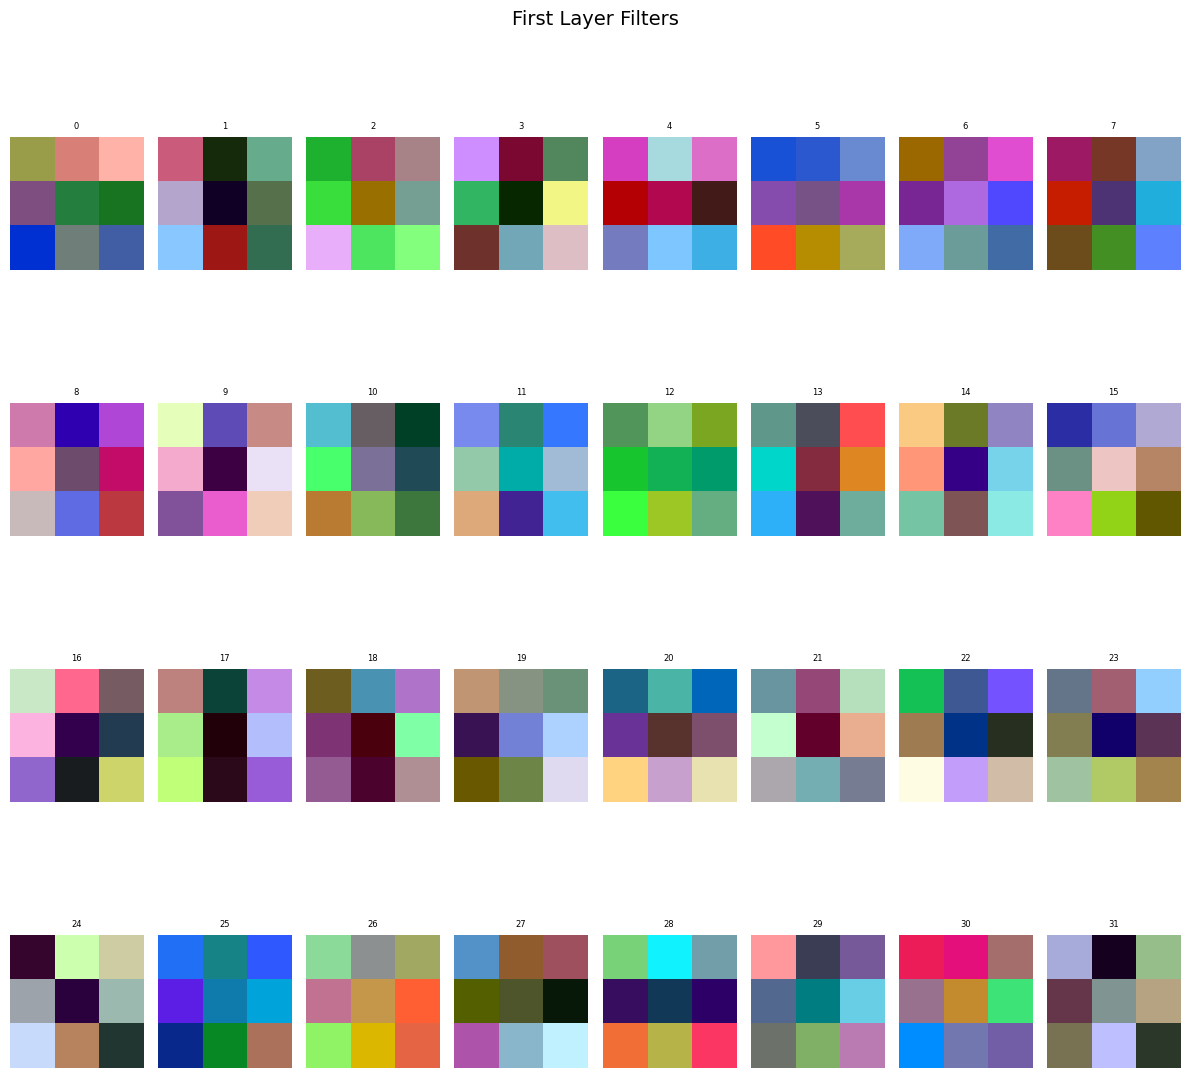

In [ ]:
model = model_cos   # or use your best trained model

first_conv = model.layers[0]

# -------- extract weights --------
filters = first_conv.get_weights()[0]   # shape: (K, K, C_in, C_out)

print("Filter shape:", filters.shape)

# -------- normalize each filter independently --------
num_filters = filters.shape[-1]

filters_norm = np.zeros_like(filters)

for i in range(num_filters):
    f = filters[:, :, :, i]
    f_min, f_max = f.min(), f.max()

    # avoid division by zero
    if f_max - f_min != 0:
        filters_norm[:, :, :, i] = (f - f_min) / (f_max - f_min)
    else:
        filters_norm[:, :, :, i] = f

# -------- plotting --------
cols = 8   # number of columns
rows = int(np.ceil(num_filters / cols))

plt.figure(figsize=(12, 12))

for i in range(num_filters):
    plt.subplot(rows, cols, i + 1)

    f = filters_norm[:, :, :, i]   # (K,K,3)

    plt.imshow(f)
    plt.axis('off')
    plt.title(str(i), fontsize=6)

plt.suptitle("First Layer Filters", fontsize=14)
plt.tight_layout()

plt.savefig("conv1_filters.png")
plt.show()

### Problem 2: Intermediate Feature Maps

Using image index: 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step


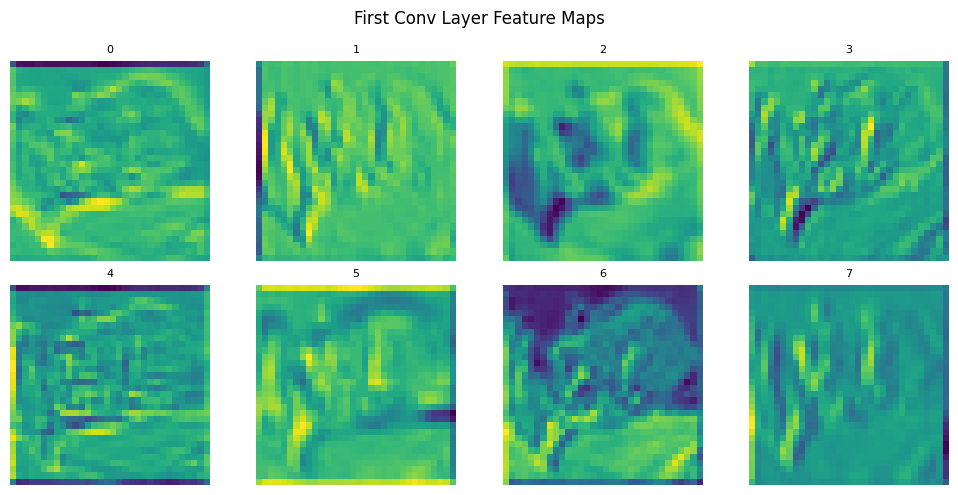

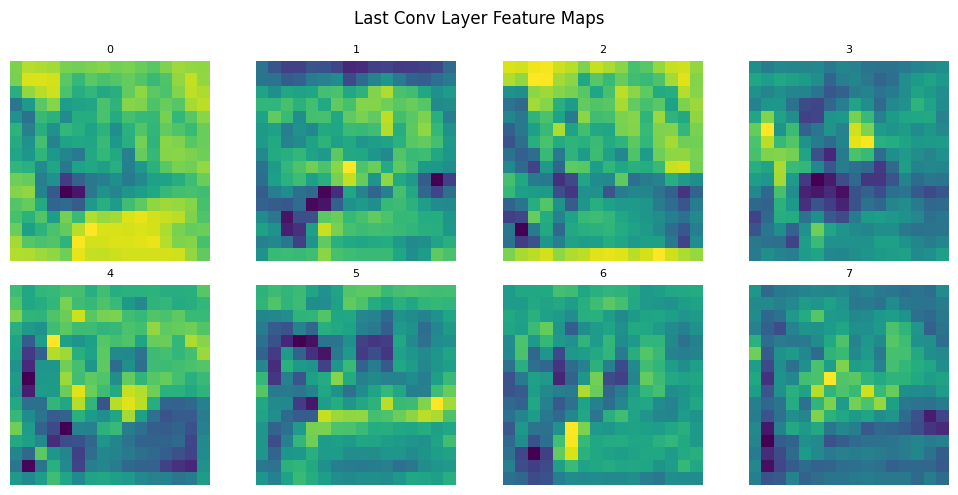

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Model

# -------- load CIFAR --------
(_, _), (x_test_cifar, y_test_cifar) = cifar10.load_data()
x_test_cifar_p = x_test_cifar.astype('float32') / 255.0

# -------- use trained model --------
model = model_cos   # or model_rlr

# -------- pick correct image --------
for i in range(len(x_test_cifar_p)):
    img = x_test_cifar_p[i:i+1]
    pred = model.predict(img, verbose=0)
    if pred.argmax() == y_test_cifar[i]:
        print("Using image index:", i)
        break

# -------- REBUILD MODEL GRAPH (KEY FIX) --------
inputs = tf.keras.Input(shape=(32,32,3))
x = inputs

conv_outputs = []

for layer in model.layers:
    x = layer(x)
    if 'conv' in layer.name:
        conv_outputs.append(x)

feature_model = Model(inputs=inputs, outputs=conv_outputs)

# -------- get feature maps --------
feature_maps = feature_model.predict(img)

# -------- FIRST layer --------
fmaps1 = feature_maps[0]

plt.figure(figsize=(10,5))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(fmaps1[0, :, :, i], cmap='viridis')
    plt.axis('off')
    plt.title(str(i), fontsize=8)

plt.suptitle("First Conv Layer Feature Maps")
plt.tight_layout()
plt.savefig("fmaps_layer1.png")
plt.show()

# -------- LAST layer --------
fmaps_last = feature_maps[-1]

plt.figure(figsize=(10,5))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(fmaps_last[0, :, :, i], cmap='viridis')
    plt.axis('off')
    plt.title(str(i), fontsize=8)

plt.suptitle("Last Conv Layer Feature Maps")
plt.tight_layout()
plt.savefig("fmaps_last.png")
plt.show()

### Problem 3: Grad-CAM Heatmap Implementation

Last conv index: 5


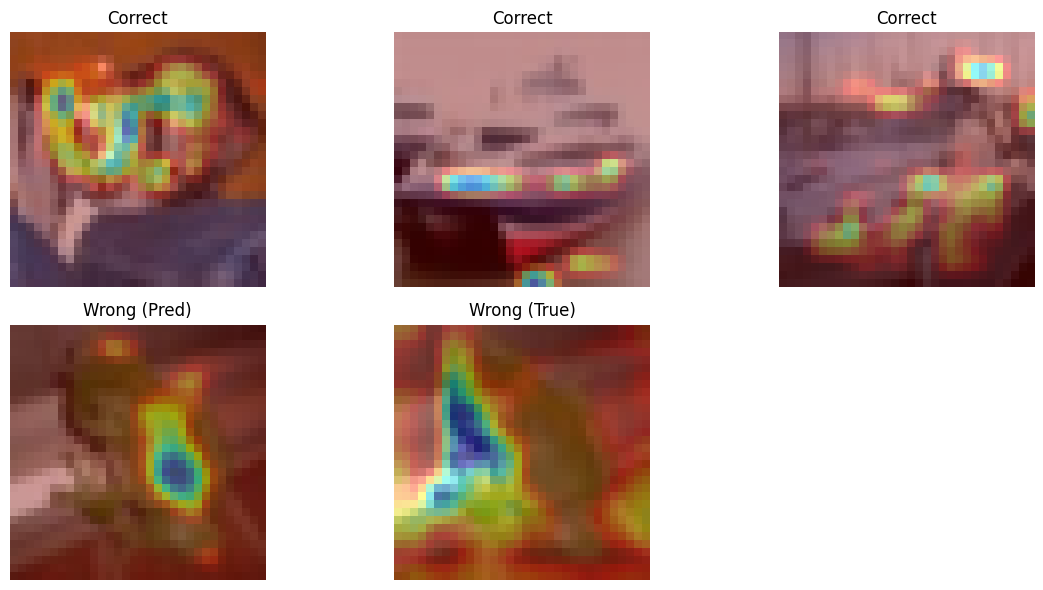

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.datasets import cifar10

# -------- load CIFAR --------
(_, _), (x_test, y_test) = cifar10.load_data()
x_test = x_test.astype('float32') / 255.0

model = model_cos   # your trained model

# -------- find last conv layer index --------
last_conv_index = None
for i in range(len(model.layers)-1, -1, -1):
    if 'conv' in model.layers[i].name:
        last_conv_index = i
        break

print("Last conv index:", last_conv_index)

# -------- Grad-CAM function (SAFE VERSION) --------
def grad_cam(img, model, class_idx):

    inputs = tf.cast(img, tf.float32)

    with tf.GradientTape() as tape:
        x = inputs
        conv_output = None

        # forward pass manually
        for i, layer in enumerate(model.layers):
            x = layer(x)
            if i == last_conv_index:
                conv_output = x

        predictions = x
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_output)

    # global average pooling
    weights = tf.reduce_mean(grads, axis=(1,2))

    # weighted sum
    cam = tf.reduce_sum(weights[:, tf.newaxis, tf.newaxis, :] * conv_output, axis=-1)

    cam = tf.nn.relu(cam)

    cam = cam[0].numpy()
    cam = cam / (cam.max() + 1e-8)

    return cam

# -------- overlay --------
def overlay_heatmap(img, heatmap):
    heatmap = cv2.resize(heatmap, (32,32))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    img = np.uint8(255 * img[0])
    overlay = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)
    return overlay

# -------- select images --------
correct_imgs = []
wrong_img = None

for i in range(len(x_test)):
    img = x_test[i:i+1]
    pred = model.predict(img, verbose=0).argmax()
    true = y_test[i][0]

    if pred == true and len(correct_imgs) < 3:
        correct_imgs.append((img, true, pred))

    if pred != true and wrong_img is None:
        wrong_img = (img, true, pred)

    if len(correct_imgs) == 3 and wrong_img is not None:
        break

# -------- generate results --------
results = []

# correct images
for img, true, pred in correct_imgs:
    heatmap = grad_cam(img, model, pred)
    overlay = overlay_heatmap(img, heatmap)
    results.append(("Correct", overlay))

# wrong image
img, true, pred = wrong_img

heat_pred = grad_cam(img, model, pred)
overlay_pred = overlay_heatmap(img, heat_pred)

heat_true = grad_cam(img, model, true)
overlay_true = overlay_heatmap(img, heat_true)

results.append(("Wrong (Pred)", overlay_pred))
results.append(("Wrong (True)", overlay_true))

# -------- plot --------
plt.figure(figsize=(12,6))

for i, (title, img) in enumerate(results):
    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.savefig("gradcam_results.png")
plt.show()

### Problem 4: Confusion Matrix & Classification Report

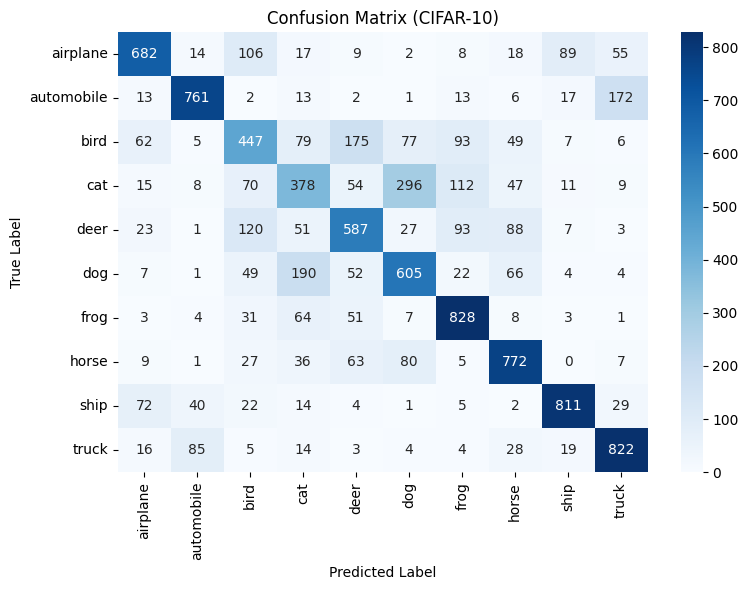

              precision    recall  f1-score   support

    airplane       0.76      0.68      0.72      1000
  automobile       0.83      0.76      0.79      1000
        bird       0.51      0.45      0.48      1000
         cat       0.44      0.38      0.41      1000
        deer       0.59      0.59      0.59      1000
         dog       0.55      0.60      0.58      1000
        frog       0.70      0.83      0.76      1000
       horse       0.71      0.77      0.74      1000
        ship       0.84      0.81      0.82      1000
       truck       0.74      0.82      0.78      1000

    accuracy                           0.67     10000
   macro avg       0.67      0.67      0.67     10000
weighted avg       0.67      0.67      0.67     10000



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.datasets import cifar10

# -------- load CIFAR test data --------
(_, _), (x_test, y_test) = cifar10.load_data()
x_test = x_test.astype('float32') / 255.0
y_test = y_test.flatten()

# -------- class names --------
class_names = [
    "airplane","automobile","bird","cat","deer",
    "dog","frog","horse","ship","truck"
]

# -------- model --------
model = model_cos   # your trained model

# -------- predictions --------
y_pred_probs = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# -------- CONFUSION MATRIX --------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (CIFAR-10)")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

# -------- CLASSIFICATION REPORT --------
report = classification_report(y_test, y_pred, target_names=class_names)
print(report)

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

# convert report to dict
report_dict = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)

# get F1 scores
f1_scores = {cls: report_dict[cls]['f1-score'] for cls in class_names}

# highest & lowest
best_class = max(f1_scores, key=f1_scores.get)
worst_class = min(f1_scores, key=f1_scores.get)

print("Best F1:", best_class)
print("Worst F1:", worst_class)

# -------- most confused pairs --------
cm_copy = cm.copy()
np.fill_diagonal(cm_copy, 0)

# get top 2 confusion pairs
pairs = np.dstack(np.unravel_index(np.argsort(cm_copy.ravel())[::-1], cm_copy.shape))[0]

top_pairs = []
for i, j in pairs:
    if len(top_pairs) == 2:
        break
    top_pairs.append((class_names[i], class_names[j]))

print("Most confused pairs:", top_pairs)

Best F1: ship
Worst F1: cat
Most confused pairs: [('cat', 'dog'), ('dog', 'cat')]


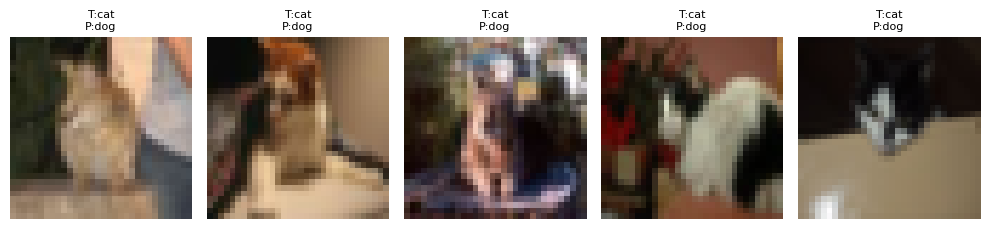

In [ ]:
# pick most confused pair
class_a, class_b = top_pairs[0]

idx_a = class_names.index(class_a)
idx_b = class_names.index(class_b)

# collect misclassified examples
misclassified = []

for i in range(len(x_test)):
    if y_test[i] == idx_a and y_pred[i] == idx_b:
        misclassified.append(i)
    if len(misclassified) == 5:
        break

# plot them
plt.figure(figsize=(10,4))

for i, idx in enumerate(misclassified):
    plt.subplot(1,5,i+1)
    plt.imshow(x_test[idx])
    plt.title(f"T:{class_a}\nP:{class_b}", fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.savefig("confused_examples.png")
plt.show()

### Task 5: Transfer Learning & Fine-Tuning

### Problem 1: Feature Extraction with a Frozen Base

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Trainable params: 133898
Frozen params: 14714688
Epoch 1/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.5397 - loss: 2.1788 - val_accuracy: 0.6715 - val_loss: 0.9750
Epoch 2/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.6667 - loss: 1.0102 - val_accuracy: 0.7025 - val_loss: 0.8953
Epoch 3/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.7091 - loss: 0.8486 - val_accuracy: 0.7125 - val_loss: 0.8733
Epoch 4/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.7309 - loss: 0.7788 - val_accuracy: 0.7270 - val_loss: 0.8253
Epoch 5/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.7498 - loss: 0.7228 - val_accuracy: 0.7225 - val_loss: 0.8321
Epoch 6/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.7633 - loss: 0.6762 - val_accuracy: 0.7250 - val_loss: 0.8266
Epoch 7/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.7794 - loss: 0.6402 - val_accuracy: 0.7325 - val_los

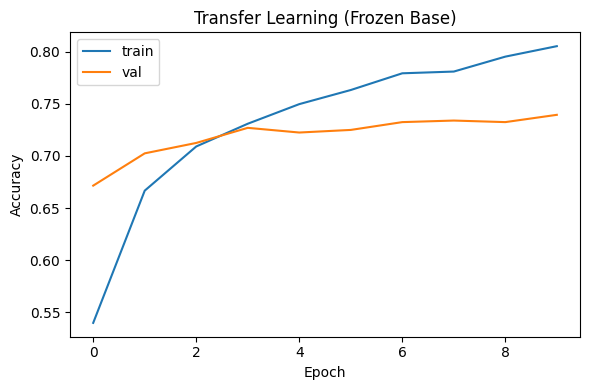

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

# -------- clear memory --------
tf.keras.backend.clear_session()

# -------- load data --------
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# -------- OPTIONAL: reduce dataset (for stability) --------
x_train = x_train[:20000]
y_train = y_train[:20000]

# -------- resize to 64x64 (lighter than 96x96) --------
x_train = tf.image.resize(x_train, (64,64))
x_test = tf.image.resize(x_test, (64,64))

# -------- preprocess --------
x_train = preprocess_input(x_train)
x_test = preprocess_input(x_test)

# -------- one-hot encode --------
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

# -------- load VGG16 --------
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(64,64,3))

# -------- freeze base --------
for layer in base_model.layers:
    layer.trainable = False

# -------- custom head --------
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(10, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# -------- print params --------
trainable_params = np.sum([np.prod(v.shape) for v in model.trainable_weights])
frozen_params = np.sum([np.prod(v.shape) for v in model.non_trainable_weights])

print("Trainable params:", trainable_params)
print("Frozen params:", frozen_params)

# -------- compile --------
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# -------- train --------
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

# -------- plot --------
plt.figure(figsize=(6,4))

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Transfer Learning (Frozen Base)")
plt.legend()

plt.tight_layout()
plt.savefig("tl_frozen.png")
plt.show()

### Problem 2: Fine-Tuning with Gradual Unfreezing

Epoch 1/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 40s 52ms/step - accuracy: 0.9628 - loss: 0.1054 - val_accuracy: 0.8215 - val_loss: 0.9154
Epoch 2/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 26s 45ms/step - accuracy: 0.9704 - loss: 0.0849 - val_accuracy: 0.8175 - val_loss: 0.8991
Epoch 3/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 25s 45ms/step - accuracy: 0.9751 - loss: 0.0743 - val_accuracy: 0.8265 - val_loss: 0.8797
Epoch 4/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 25s 45ms/step - accuracy: 0.9779 - loss: 0.0650 - val_accuracy: 0.8290 - val_loss: 0.9299
Epoch 5/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 25s 45ms/step - accuracy: 0.9777 - loss: 0.0655 - val_accuracy: 0.8330 - val_loss: 0.9222
Epoch 6/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 25s 45ms/step - accuracy: 0.9838 - loss: 0.0494 - val_accuracy: 0.8430 - val_loss: 0.9054
Epoch 7/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 25s 45ms/step - accuracy: 0.9843 - loss: 0.0489 - val_accuracy: 0.8350 - val_loss: 0.9729
Epoch 8/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 25s 45ms/step - accuracy: 0.9842 - loss: 0.0470 - 

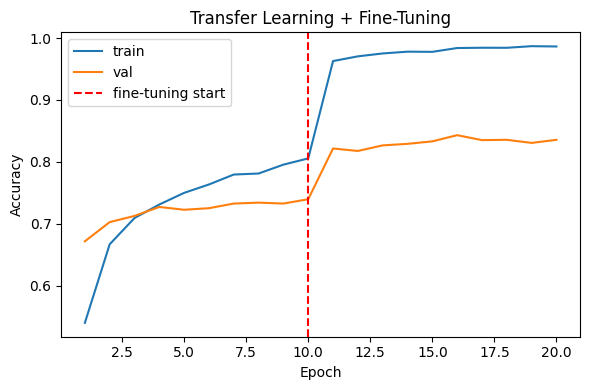

Best validation accuracy at epoch: 16


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# -------- Step 1: Unfreeze last 4 conv layers --------
conv_layers = [layer for layer in base_model.layers if 'conv' in layer.name]

for layer in conv_layers[-4:]:
    layer.trainable = True

for layer in conv_layers[:-4]:
    layer.trainable = False

# -------- Step 2: RECOMPILE (CRITICAL) --------
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# -------- Step 3: EarlyStopping --------
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

# -------- Step 4: Fine-tune --------
history_ft = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop]
)

# -------- Step 5: Combine histories --------
train_acc = history.history['accuracy'] + history_ft.history['accuracy']
val_acc = history.history['val_accuracy'] + history_ft.history['val_accuracy']

epochs = range(1, len(train_acc) + 1)

# -------- Step 6: Plot --------
plt.figure(figsize=(6,4))

plt.plot(epochs, train_acc, label='train')
plt.plot(epochs, val_acc, label='val')

# mark transition point
plt.axvline(x=10, color='red', linestyle='--', label='fine-tuning start')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Transfer Learning + Fine-Tuning")
plt.legend()

plt.tight_layout()
plt.savefig("tl_finetuned.png")
plt.show()

# -------- Step 7: Best epoch --------
best_epoch = np.argmax(history_ft.history['val_accuracy']) + 11
print("Best validation accuracy at epoch:", best_epoch)

### Problem 3: Unfreezing Ablation Study

In [ ]:
def run_finetune(num_layers_unfreeze):

    tf.keras.backend.clear_session()

    # reload base model
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(64,64,3))

    # freeze all first
    for layer in base_model.layers:
        layer.trainable = False

    # unfreeze last N layers
    for layer in base_model.layers[-num_layers_unfreeze:]:
        layer.trainable = True

    # build head again
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(10, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)

    # count params
    trainable_params = np.sum([np.prod(v.shape) for v in model.trainable_weights])

    # compile
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # train
    history = model.fit(
        x_train, y_train,
        epochs=10,
        batch_size=32,
        validation_split=0.1,
        verbose=0
    )

    # metrics
    train_acc = history.history['accuracy'][-1]
    val_acc = max(history.history['val_accuracy'])

    gap = train_acc - val_acc
    overfit = gap > 0.05

    return trainable_params, val_acc, overfit

In [ ]:
res_2 = run_finetune(2)
res_8 = run_finetune(8)
res_all = run_finetune(len(base_model.layers))

### Problem 4: Benchmark: Scratch vs Transfer Learning

In [ ]:
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [ ]:
from tensorflow.keras.utils import to_categorical

# normalize (IMPORTANT: float32)
x_train_cifar_p = x_train.astype('float32') / 255.0
x_test_cifar_p = x_test.astype('float32') / 255.0

# one-hot encode labels
y_train_cifar_p = to_categorical(y_train, 10)
y_test_cifar_p = to_categorical(y_test, 10)

# check shapes
print(x_train_cifar_p.shape, y_train_cifar_p.shape)

(50000, 32, 32, 3) (50000, 10)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

model_scratch = models.Sequential([
    tf.keras.Input(shape=(32,32,3)),

    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model_scratch.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_scratch.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,946 (437.29 KB)

 Trainable params: 111,498 (435.54 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
history_scratch = model_scratch.fit(
    x_train_cifar_p, y_train_cifar_p,
    validation_split=0.1,
    epochs=15,
    batch_size=64,
    verbose=1
)

Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.4243 - loss: 1.5761 - val_accuracy: 0.4232 - val_loss: 1.6633
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5513 - loss: 1.2597 - val_accuracy: 0.5678 - val_loss: 1.1665
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5998 - loss: 1.1300 - val_accuracy: 0.5914 - val_loss: 1.1383
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6268 - loss: 1.0542 - val_accuracy: 0.5752 - val_loss: 1.1801
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6522 - loss: 0.9864 - val_accuracy: 0.6394 - val_loss: 1.0192
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6723 - loss: 0.9337 - val_accuracy: 0.6578 - val_loss: 0.9648
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6919 - loss: 0.8804 - val_accuracy: 0.6838 - val_loss: 0.8779
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7056 - loss: 0.8399 - val_accuracy: 

Q1. Explain the concept of 'negative transfer'. Under what conditions might using ImageNet pre-trained
weights actually hurt performance rather than help? Give a concrete example of a domain where you would
expect negative transfer.

Negative transfer happens when using a pre-trained model actually makes the performance worse instead of improving it. This usually occurs when the source dataset (like ImageNet) is very different from the target dataset, so the learned features are not relevant.

ImageNet models are trained on natural RGB images like animals and everyday objects. If the new dataset has very different characteristics, such as grayscale images or very different patterns, the pre-trained features may confuse the model instead of helping it.

Negative transfer is more likely when:

The domains are very different (e.g., natural images vs medical images)
The input format is different (RGB vs grayscale)
The task requires very specific features not present in ImageNet

Example:
In medical imaging such as X-rays, images are grayscale and contain subtle patterns. Features learned from ImageNet like textures of animals or object edges are not useful here, so using pre-trained weights may hurt performance.

Q2. In your ablation (Problem 3), unfreezing all layers likely led to more overfitting than unfreezing only the
top few. Explain the bias-variance trade-off at play here. Why do the lower layers of a CNN trained on
ImageNet generalise better than the upper layers?

This situation relates to the bias-variance trade-off. When we unfreeze all layers, the model becomes very flexible (low bias), but it also becomes more likely to overfit the training data (high variance).

Lower layers of a CNN learn very basic features such as edges, corners, and simple textures. These features are general and useful across many different datasets, so they tend to generalise well.

On the other hand, higher layers learn more complex and task-specific features, like shapes of specific objects. When we unfreeze all layers, these deeper layers start adapting too much to the new dataset, which can lead to overfitting, especially if the dataset is small.

That is why unfreezing only the top few layers often works better — it allows adaptation while still keeping the strong general features from the pre-trained model.

Q3. Your benchmark (Problem 4) compares parameter counts and accuracy across models. In a real
deployment scenario — e.g., a mobile app — what other factors beyond accuracy would influence your
choice of model? Name at least three and explain each.

Model size:
Smaller models are preferred for mobile apps because they take less storage space and are easier to download and deploy.
Inference speed (latency):
The model should make predictions quickly. A slow model can lead to poor user experience, especially in real-time applications.
Memory usage:
Mobile devices have limited RAM, so the model should not consume too much memory while running.
Power consumption:
Efficient models are important to avoid draining the device battery quickly.

Q4. Suppose you have a completely new medical imaging dataset (X-ray scans, grayscale, 512×512) with
only 500 labelled training examples. Write a step-by-step transfer learning strategy you would follow,
justifying every choice (which base model, how many layers to freeze, learning rate, augmentation, etc.).

For a small medical dataset (like 500 X-ray images), I would follow this strategy:

Choose a pre-trained model:
I would use a model like ResNet or VGG trained on ImageNet, because it already has strong feature extraction capabilities.
Adjust input:
Since X-rays are grayscale, I would either convert them to 3 channels or modify the input layer accordingly.
Freeze most layers:
Initially, I would freeze almost all convolutional layers to retain general features and avoid overfitting due to the small dataset.
Add a custom classification head:
I would add layers like GlobalAveragePooling, Dense, and Dropout to adapt the model to the new task.
Train only the head:
First train only the new layers with a moderate learning rate (e.g., 0.001).
Fine-tune selectively:
Then unfreeze a few top layers and train with a very small learning rate (e.g., 1e-5) to slightly adapt the model.
Apply data augmentation:
Since data is limited, I would use augmentation like rotation, zoom, and flips (only if medically valid) to increase data diversity.
Use regularisation:
Apply dropout and early stopping to prevent overfitting.